In [1]:
# Remember that Colab gives you a temporary computer in Google's cloud and runs R there.
install.packages("C50")
install.packages("gmodels")

# so in here, Colab is actually installing those packages into the R library of your temporary cloud machine.

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘plyr’, ‘zoo’, ‘sandwich’, ‘reshape2’, ‘libcoin’, ‘mvtnorm’, ‘Formula’, ‘inum’, ‘strucchange’, ‘Cubist’, ‘partykit’


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘gtools’, ‘gdata’




In [2]:
# Your saved notebook
#         │
#         ↓
# ┌──────────────────────────┐
# │ Temporary Colab runtime  │
# │                          │
# │ Installed packages       │
# │ Uploaded iris.csv        │
# │ Variables                │
# │ model                    │
# │ train_data               │
# │ predictions              │
# │ etc.                     │
# └──────────────────────────┘


# so for example, we ran a couple of lines of code and saved some varaibles in here those variables will only be saved in that specific runtime if it resets the code will still be there but the runtime will start fresh


require(C50)
require(gmodels)

Loading required package: C50

Loading required package: gmodels



In [4]:
# so, so far we only did this

# install.packages("C50")
#         ↓
# Put C50 onto this Colab runtime

# require(C50)
#         ↓
# Load C50 into the current R session


# header = true -> that this file includes headers and stringsasfactors -> When loading the CSV, keep text as ordinary character strings instead of automatically converting it into categorical factors.
# for StringsAsFactos -> To initially keep text values as normal text.
dataset = read.csv("iris.csv", header = TRUE, stringsAsFactors = FALSE)
head(dataset)

,sepal.length,sepal.width,petal.length,petal.width,variety
,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
1,5.1,3.5,1.4,0.2,Setosa
2,4.9,3.0,1.4,0.2,Setosa
3,4.7,3.2,1.3,0.2,Setosa
4,4.6,3.1,1.5,0.2,Setosa
5,5.0,3.6,1.4,0.2,Setosa
6,5.4,3.9,1.7,0.4,Setosa


In [5]:
print("Dataset Structure:")
str(dataset)

[1] "Dataset Structure:"
'data.frame':	150 obs. of  5 variables:
 $ sepal.length: num  5.1 4.9 4.7 4.6 5 5.4 4.6 5 4.4 4.9 ...
 $ sepal.width : num  3.5 3 3.2 3.1 3.6 3.9 3.4 3.4 2.9 3.1 ...
 $ petal.length: num  1.4 1.4 1.3 1.5 1.4 1.7 1.4 1.5 1.4 1.5 ...
 $ petal.width : num  0.2 0.2 0.2 0.2 0.2 0.4 0.3 0.2 0.2 0.1 ...
 $ variety     : chr  "Setosa" "Setosa" "Setosa" "Setosa" ...


In [6]:
# Set the seed so the random shuffle can be reproduced
set.seed(123)

# nrow(dataset) -> how many rows are in our dataset (150) so this part sample(nrow(dataset)) is basically saying sample(150)
# dataset[sample(nrow(dataset)), ] -> Give me all the rows, but in this new random order, and keep all the columns
dataset <- dataset[sample(nrow(dataset)), ]

# View the shuffled dataset
View(dataset)

,sepal.length,sepal.width,petal.length,petal.width,variety
,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
14,4.3,3.0,1.1,0.1,Setosa
50,5.0,3.3,1.4,0.2,Setosa
118,7.7,3.8,6.7,2.2,Virginica
43,4.4,3.2,1.3,0.2,Setosa
150,5.9,3.0,5.1,1.8,Virginica
148,6.5,3.0,5.2,2.0,Virginica
90,5.5,2.5,4.0,1.3,Versicolor
91,5.5,2.6,4.4,1.2,Versicolor
143,5.8,2.7,5.1,1.9,Virginica


In [7]:
# Calculate 70% of the total number of rows
train_size <- floor(0.7 * nrow(dataset))

# First 70% becomes training data -> so 1: trainsize is pretty much 70% of the rows of the full data (so: Rows 1–105 → training data)
train_data <- dataset[1:train_size, ]

# Remaining 30% becomes testing data and in addition -> The + 1 means after the trainning row so this row pretty much becomes test_data <- dataset[106:150, ]
# the usual space as in after the comma means all the columns
test_data <- dataset[(train_size + 1):nrow(dataset), ]

# Display information about the split
print(paste("Total rows:", nrow(dataset)))
print(paste("Training set size:", nrow(train_data), "(70%)"))
print(paste("Testing set size:", nrow(test_data), "(30%)"))

[1] "Total rows: 150"
[1] "Training set size: 105 (70%)"
[1] "Testing set size: 45 (30%)"


In [8]:
# Convert the target variable 'variety' into a factor
# because variety is a categorical variable


# $ means target this specific column in this dataset, Take the variety column, convert it from text into a categorical factor, and save it back into the same variety column

# why did we do this: Because variety is our categorical target variable with three classes, so we convert it to a factor for classification.
train_data$variety <- as.factor(train_data$variety)
test_data$variety <- as.factor(test_data$variety)

In [9]:
# Train the C5.0 Decision Tree using the training data
#
# Columns 1-4 = input features:
# sepal.length, sepal.width, petal.length, petal.width
#
# Column 5 = target:
# variety

# train_data[, -5] -> Use all columns EXCEPT column 5


# This trains the C5.0 decision tree using columns 1 to 4 as the input features and column 5, variety, as the target class and saves the decision tree into an object called model.
model <- C5.0(train_data[, -5], train_data[, 5])

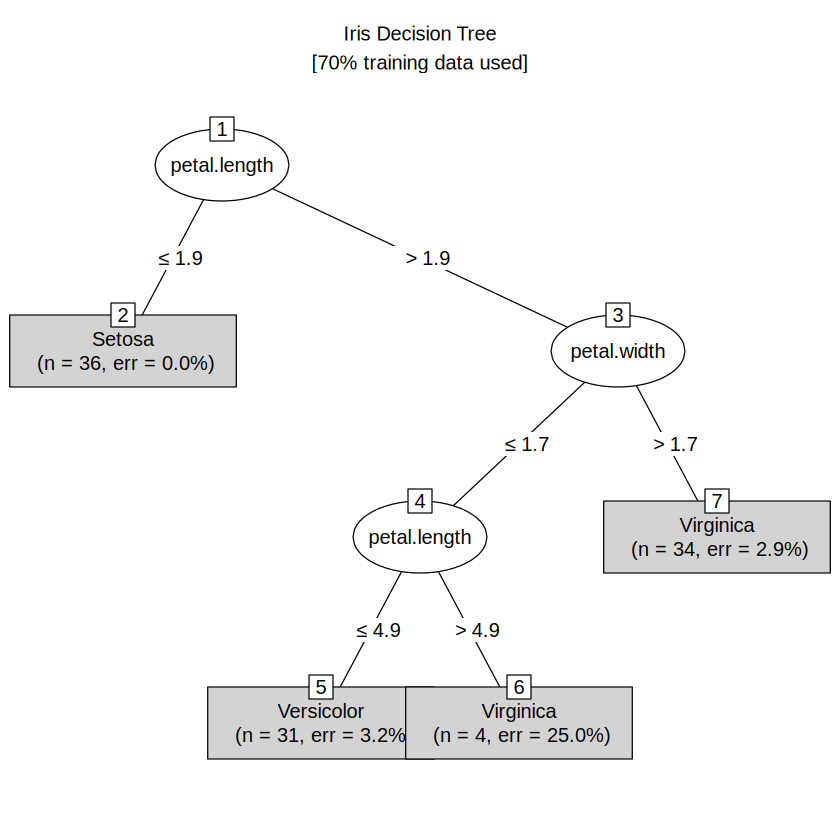

In [10]:
# Plot the decision tree learned from the training data

plot(model, type = "s", main = "Iris Decision Tree\n[70% training data used]")

In [11]:
# Display detailed information about the trained model

# The tree used mainly petal length and petal width to classify the flowers. It created four terminal rules and made only 3 errors out of 105 training samples, giving approximately 97.1% training accuracy.

print("\n=== TRAINING DATA PERFORMANCE ===")
summary(model)

[1] "\n=== TRAINING DATA PERFORMANCE ==="



Call:
C5.0.default(x = train_data[, -5], y = train_data[, 5])


C5.0 [Release 2.07 GPL Edition]  	Sun Oct  4 19:46:24 2026
-------------------------------

Class specified by attribute `outcome'

Read 105 cases (5 attributes) from undefined.data

Decision tree:

petal.length <= 1.9: Setosa (36)
petal.length > 1.9:
:...petal.width > 1.7: Virginica (34/1)
    petal.width <= 1.7:
    :...petal.length <= 4.9: Versicolor (31/1)
        petal.length > 4.9: Virginica (4/1)


Evaluation on training data (105 cases):

	    Decision Tree   
	  ----------------  
	  Size      Errors  

	     4    3( 2.9%)   <<


	   (a)   (b)   (c)    <-classified as
	  ----  ----  ----
	    36                (a): class Setosa
	          30     2    (b): class Versicolor
	           1    36    (c): class Virginica


	Attribute usage:

	100.00%	petal.length
	 65.71%	petal.width


Time: 0.0 secs


In [12]:
# Make predictions on the TEST data
#
# Column 5 is excluded because it contains the actual answer.
# The model should only receive the four flower measurements.

predictions <- predict(model, test_data[, -5])

# View the predictions
View(as.data.frame(predictions))

# Put test_data and predictions side-by-side, then show me the result
View(cbind(test_data, predictions))

predictions
<fct>
Versicolor
Virginica
Virginica
Setosa
Virginica
Setosa
Virginica
Virginica
Virginica


,sepal.length,sepal.width,petal.length,petal.width,variety,predictions
,<dbl>,<dbl>,<dbl>,<dbl>,<fct>,<fct>
68,5.8,2.7,4.1,1.0,Versicolor,Versicolor
133,6.4,2.8,5.6,2.2,Virginica,Virginica
145,6.7,3.3,5.7,2.5,Virginica,Virginica
29,5.2,3.4,1.4,0.2,Setosa,Setosa
104,6.3,2.9,5.6,1.8,Virginica,Virginica
45,5.1,3.8,1.9,0.4,Setosa,Setosa
140,6.9,3.1,5.4,2.1,Virginica,Virginica
101,6.3,3.3,6.0,2.5,Virginica,Virginica
135,6.1,2.6,5.6,1.4,Virginica,Virginica


In [13]:
# Compare the actual species with the predicted species

print("\n=== TESTING DATA PERFORMANCE ===")
print("Confusion Matrix on Test Set:")

confusion_matrix <- table(
  Actual = test_data$variety,
  Predicted = predictions
)


# 1 Versicolor → incorrectly predicted Virginica
print(confusion_matrix)

[1] "\n=== TESTING DATA PERFORMANCE ==="
[1] "Confusion Matrix on Test Set:"
            Predicted
Actual       Setosa Versicolor Virginica
  Setosa         14          0         0
  Versicolor      0         17         1
  Virginica       0          0        13


In [14]:
# Calculate test accuracy
# Correct predictions / Total predictions


# diag() extracts the diagonal values from the confusion matrix, which represent the correctly classified samples.
accuracy <- sum(diag(confusion_matrix)) / sum(confusion_matrix)


# paste() combines the text, the calculated accuracy, and the percentage symbol into one output message.
print(paste("Test Set Accuracy:",round(accuracy * 100, 2),"%")
)

[1] "Test Set Accuracy: 97.78 %"


In [15]:
# Calculate the number of incorrect predictions

errors <- sum(confusion_matrix) - sum(diag(confusion_matrix))

print(paste("Number of Incorrect Predictions:", errors))

# Calculate the error rate

error_rate <- 1 - accuracy

print(
  paste(
    "Test Set Error Rate:",
    round(error_rate * 100, 2),
    "%"
  )
)

[1] "Number of Incorrect Predictions: 1"
[1] "Test Set Error Rate: 2.22 %"
